# Librerías y configuración inicial

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
from itertools import product
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score

sns.set_style("whitegrid")

# Carga de datos

In [2]:
current = Path.cwd()
file_path = current.parent / "data" / "model_data" / "model_data.parquet"
if not file_path.exists():
    raise FileNotFoundError(f"[ERROR] No se encontró el archivo: {file_path}")

df = pd.read_parquet(file_path)
df = df.sort_values("datetime") # Ordenamos por si acaso

# Preparación de conjuntos de pruebas y test

In [3]:
# Dividimos los datos entre train con los años de 2019 a 2024, y los de test serán el año 2025
split_date = "2025-01-01"
train = df[df["datetime"] < split_date].copy()
test  = df[df["datetime"] >= split_date].copy()

print("Train shape:", train.shape)
print("Test shape :", test.shape)

Train shape: (52440, 46)
Test shape : (8760, 46)


In [4]:
# Variables predictoras (features)
feature_cols = [col for col in df.columns if col not in ["datetime", "demanda", "precio"]]
x_train = train[feature_cols]
x_test  = test[feature_cols]

# Objetivo: demanda
y_train_demanda = train["demanda"]
y_test_demanda  = test["demanda"]

# Objetivo: precio
y_train_precio = train["precio"]
y_test_precio  = test["precio"]

print(f"Número de variables predictoras: {len(feature_cols)}")

Número de variables predictoras: 43


# Baseline

In [5]:
# Baselines de demanda y precio, usaremos lag_1 para medir persistencia inmediata, y lag_24 para medir repetición diaria

# Demanda
baseline_demanda_lag1  = test["demanda_lag_1"]
baseline_demanda_lag24 = test["demanda_lag_24"]

mae_d_lag1  = mean_absolute_error(y_test_demanda, baseline_demanda_lag1)
rmse_d_lag1 = np.sqrt(mean_squared_error(y_test_demanda, baseline_demanda_lag1))
mape_d_lag1 = mean_absolute_percentage_error(y_test_demanda, baseline_demanda_lag1)
r2_d_lag1   = r2_score(y_test_demanda, baseline_demanda_lag1)

mae_d_lag24  = mean_absolute_error(y_test_demanda, baseline_demanda_lag24)
rmse_d_lag24 = np.sqrt(mean_squared_error(y_test_demanda, baseline_demanda_lag24))
mape_d_lag24 = mean_absolute_percentage_error(y_test_demanda, baseline_demanda_lag24)
r2_d_lag24   = r2_score(y_test_demanda, baseline_demanda_lag24)


# Precio
baseline_precio_lag1  = test["precio_lag_1"]
baseline_precio_lag24 = test["precio_lag_24"]

mae_p_lag1  = mean_absolute_error(y_test_precio, baseline_precio_lag1)
rmse_p_lag1 = np.sqrt(mean_squared_error(y_test_precio, baseline_precio_lag1))
mape_p_lag1 = mean_absolute_percentage_error(y_test_precio, baseline_precio_lag1)
r2_p_lag1   = r2_score(y_test_precio, baseline_precio_lag1)

mae_p_lag24  = mean_absolute_error(y_test_precio, baseline_precio_lag24)
rmse_p_lag24 = np.sqrt(mean_squared_error(y_test_precio, baseline_precio_lag24))
mape_p_lag24 = mean_absolute_percentage_error(y_test_precio, baseline_precio_lag24)
r2_p_lag24   = r2_score(y_test_precio, baseline_precio_lag24)


# Comparamos resultados en un dataframe
baseline_results = pd.DataFrame({
    "baseline" : ["lag_1", "lag_24", "lag_1", "lag_24"],
    "Target"   : ["Demanda", "Demanda", "Precio", "Precio"],
    "MAE"      : [mae_d_lag1, mae_d_lag24, mae_p_lag1, mae_p_lag24],
    "RMSE"     : [rmse_d_lag1, rmse_d_lag24, rmse_p_lag1, rmse_p_lag24],
    "MAPE"     : [mape_d_lag1, mape_d_lag24, mape_p_lag1, mape_p_lag24],
    "R2"       : [r2_d_lag1, r2_d_lag24, r2_p_lag1, r2_p_lag24]
})

print(baseline_results)

  baseline   Target          MAE         RMSE          MAPE        R2
0    lag_1  Demanda  1015.385496  1375.019755  4.055371e-02  0.902544
1   lag_24  Demanda  1829.762936  2825.980483  7.657173e-02  0.588347
2    lag_1   Precio     8.909957    15.493049  1.633789e+14  0.887406
3   lag_24   Precio    19.580822    28.472456  1.156479e+15  0.619732


# Entrenamiento inicial de modelos

In [6]:
# Modelos base que usaremos para cada caso, sin definir aún hiperparámetros específicos
modelos_demanda = {
    "LinearRegression" : LinearRegression(),
    "RandomForest"     : RandomForestRegressor(random_state=42, n_jobs=-1),
    "XGBoost"          : XGBRegressor(random_state=42, n_jobs=-1)
}

modelos_precio = {
    "LinearRegression" : LinearRegression(),
    "RandomForest"     : RandomForestRegressor(random_state=42, n_jobs=-1),
    "XGBoost"          : XGBRegressor(random_state=42, n_jobs=-1)
}

In [7]:
# Entrenamiento con evaluación, para cada modelo, de demanda
resultados_demanda = []

for nombre, modelo in modelos_demanda.items():

    modelo.fit(x_train, y_train_demanda)

    pred = modelo.predict(x_test)

    mae  = mean_absolute_error(y_test_demanda, pred)
    mse  = mean_squared_error(y_test_demanda, pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_test_demanda, pred)
    r2   = r2_score(y_test_demanda, pred)

    resultados_demanda.append({
        "Target" : "Demanda",
        "Modelo" : nombre,
        "MAE"    : mae,
        "RMSE"   : rmse,
        "MAPE"   : mape,
        "R2"     : r2
    })

resultados_demanda = pd.DataFrame(resultados_demanda)
display(resultados_demanda.sort_values("RMSE", ignore_index=True))

,Target,Modelo,MAE,RMSE,MAPE,R2
0,Demanda,RandomForest,291.449903,575.157552,0.017430,0.982948
1,Demanda,XGBoost,283.842119,586.311271,0.017841,0.982281
2,Demanda,LinearRegression,443.138653,621.110412,0.018526,0.980115


In [8]:
# Entrenamiento con evaluación, para cada modelo, de precio
resultados_precio = []

for nombre, modelo in modelos_precio.items():

    modelo.fit(x_train, y_train_precio)

    pred = modelo.predict(x_test)

    mae  = mean_absolute_error(y_test_precio, pred)
    mse  = mean_squared_error(y_test_precio, pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_test_precio, pred)
    r2   = r2_score(y_test_precio, pred)

    resultados_precio.append({
        "Target" : "Precio",
        "Modelo" : nombre,
        "MAE"    : mae,
        "RMSE"   : rmse,
        "MAPE"   : mape,
        "R2"     : r2
    })

resultados_precio = pd.DataFrame(resultados_precio)
display(resultados_precio.sort_values("RMSE", ignore_index=True))

,Target,Modelo,MAE,RMSE,MAPE,R2
0,Precio,XGBoost,7.013611,10.478710,3.685982e+14,0.948494
1,Precio,RandomForest,7.020601,11.221845,2.370039e+14,0.940930
2,Precio,LinearRegression,7.642705,11.850507,6.921056e+14,0.934126


# Ajuste de hiperparámetros

In [9]:
# Random Forest
rf_results = []

n_estimators_list     = [100, 200]
max_depth_list        = [10, 15, 20]
min_samples_leaf_list = [1, 2]

for n_estimators, max_depth, min_samples_leaf in product(n_estimators_list, max_depth_list, min_samples_leaf_list):

    print(f"Random Forest - Valores de los hiperparámetros: " f"n_estimators={n_estimators}, " f"max_depth={max_depth}, " f"min_samples_leaf={min_samples_leaf}")

    model = RandomForestRegressor(
        n_estimators     = n_estimators,
        max_depth        = max_depth,
        min_samples_leaf = min_samples_leaf,
        random_state     = 42,
        n_jobs           = -1
    )

    # Demanda
    model.fit(x_train, y_train_demanda)
    pred_demanda = model.predict(x_test)
    rmse_demanda = np.sqrt(mean_squared_error(y_test_demanda, pred_demanda))

    # Precio
    model.fit(x_train, y_train_precio)
    pred_precio = model.predict(x_test)
    rmse_precio = np.sqrt(mean_squared_error(y_test_precio, pred_precio))

    rf_results.append({
        "n_estimators"     : n_estimators,
        "max_depth"        : max_depth,
        "min_samples_leaf" : min_samples_leaf,
        "RMSE_demanda"     : rmse_demanda,
        "RMSE_precio"      : rmse_precio
    })

rf_results = pd.DataFrame(rf_results)
display(rf_results.sort_values("RMSE_precio", ignore_index=True))

Random Forest - Valores de los hiperparámetros: n_estimators=100, max_depth=10, min_samples_leaf=1
Random Forest - Valores de los hiperparámetros: n_estimators=100, max_depth=10, min_samples_leaf=2
Random Forest - Valores de los hiperparámetros: n_estimators=100, max_depth=15, min_samples_leaf=1
Random Forest - Valores de los hiperparámetros: n_estimators=100, max_depth=15, min_samples_leaf=2
Random Forest - Valores de los hiperparámetros: n_estimators=100, max_depth=20, min_samples_leaf=1
Random Forest - Valores de los hiperparámetros: n_estimators=100, max_depth=20, min_samples_leaf=2
Random Forest - Valores de los hiperparámetros: n_estimators=200, max_depth=10, min_samples_leaf=1
Random Forest - Valores de los hiperparámetros: n_estimators=200, max_depth=10, min_samples_leaf=2
Random Forest - Valores de los hiperparámetros: n_estimators=200, max_depth=15, min_samples_leaf=1
Random Forest - Valores de los hiperparámetros: n_estimators=200, max_depth=15, min_samples_leaf=2
Random For

,n_estimators,max_depth,min_samples_leaf,RMSE_demanda,RMSE_precio
0,200,20,2,574.838126,11.130399
1,100,20,2,574.344598,11.148254
2,200,15,2,577.193006,11.169926
3,200,20,1,575.114237,11.181907
4,100,15,2,576.559227,11.182925
5,100,20,1,575.417456,11.212974
6,200,15,1,578.071535,11.244708
7,100,15,1,578.158571,11.266147
8,200,10,2,626.189522,11.676128
9,100,10,2,625.406760,11.687305


In [10]:
# XGBoost
xgb_results = []

n_estimators_list  = [100, 200]
max_depth_list     = [4, 6, 8]
learning_rate_list = [0.05, 0.1]

for n_estimators, max_depth, learning_rate in product(n_estimators_list, max_depth_list, learning_rate_list):

    print(f"XGBoost - Valores de los hiperparámetros: " f"n_estimators={n_estimators}, " f"max_depth={max_depth}, " f"learning_rate={learning_rate}")

    model = XGBRegressor(
        n_estimators  = n_estimators,
        max_depth     = max_depth,
        learning_rate = learning_rate,
        random_state  = 42,
        n_jobs        = -1
    )

    # Demanda
    model.fit(x_train, y_train_demanda)
    pred_demanda = model.predict(x_test)
    rmse_demanda = np.sqrt(mean_squared_error(y_test_demanda, pred_demanda))

    # Precio
    model.fit(x_train, y_train_precio)
    pred_precio = model.predict(x_test)
    rmse_precio = np.sqrt(mean_squared_error(y_test_precio, pred_precio))

    xgb_results.append({
        "n_estimators"  : n_estimators,
        "max_depth"     : max_depth,
        "learning_rate" : learning_rate,
        "RMSE_demanda"  : rmse_demanda,
        "RMSE_precio"   : rmse_precio
    })

xgb_results = pd.DataFrame(xgb_results)
display(xgb_results.sort_values("RMSE_precio", ignore_index=True))

XGBoost - Valores de los hiperparámetros: n_estimators=100, max_depth=4, learning_rate=0.05
XGBoost - Valores de los hiperparámetros: n_estimators=100, max_depth=4, learning_rate=0.1
XGBoost - Valores de los hiperparámetros: n_estimators=100, max_depth=6, learning_rate=0.05
XGBoost - Valores de los hiperparámetros: n_estimators=100, max_depth=6, learning_rate=0.1
XGBoost - Valores de los hiperparámetros: n_estimators=100, max_depth=8, learning_rate=0.05
XGBoost - Valores de los hiperparámetros: n_estimators=100, max_depth=8, learning_rate=0.1
XGBoost - Valores de los hiperparámetros: n_estimators=200, max_depth=4, learning_rate=0.05
XGBoost - Valores de los hiperparámetros: n_estimators=200, max_depth=4, learning_rate=0.1
XGBoost - Valores de los hiperparámetros: n_estimators=200, max_depth=6, learning_rate=0.05
XGBoost - Valores de los hiperparámetros: n_estimators=200, max_depth=6, learning_rate=0.1
XGBoost - Valores de los hiperparámetros: n_estimators=200, max_depth=8, learning_rat

,n_estimators,max_depth,learning_rate,RMSE_demanda,RMSE_precio
0,200,6,0.10,575.681990,10.181986
1,100,8,0.10,572.721327,10.296372
2,200,8,0.10,565.419997,10.299955
3,200,8,0.05,560.272168,10.327564
4,100,6,0.10,590.652574,10.338049
5,200,6,0.05,589.281121,10.401056
6,100,8,0.05,581.664380,10.700217
7,200,4,0.10,628.332565,10.867492
8,100,6,0.05,623.688504,10.934218
9,100,4,0.10,669.366655,11.347177


In [11]:
# Mejores hiperparámetros para cada caso

# Demanda
best_rf_demanda  = rf_results.sort_values("RMSE_demanda").iloc[0]
best_xgb_demanda = xgb_results.sort_values("RMSE_demanda").iloc[0]

# Precio
best_rf_precio  = rf_results.sort_values("RMSE_precio").iloc[0]
best_xgb_precio = xgb_results.sort_values("RMSE_precio").iloc[0]

# Resumen de la mejor configuración para cada caso
best_models = pd.DataFrame([
    {
        "Target"           : "Demanda",
        "Modelo"           : "RandomForest",
        "RMSE"             : best_rf_demanda["RMSE_demanda"],
        "n_estimators"     : best_rf_demanda["n_estimators"],
        "max_depth"        : best_rf_demanda["max_depth"],
        "min_samples_leaf" : best_rf_demanda["min_samples_leaf"],
        "learning_rate"    : np.nan
    },
    {
        "Target"           : "Demanda",
        "Modelo"           : "XGBoost",
        "RMSE"             : best_xgb_demanda["RMSE_demanda"],
        "n_estimators"     : best_xgb_demanda["n_estimators"],
        "max_depth"        : best_xgb_demanda["max_depth"],
        "min_samples_leaf" : np.nan,
        "learning_rate"    : best_xgb_demanda["learning_rate"]
    },
    {
        "Target"           : "Precio",
        "Modelo"           : "RandomForest",
        "RMSE"             : best_rf_precio["RMSE_precio"],
        "n_estimators"     : best_rf_precio["n_estimators"],
        "max_depth"        : best_rf_precio["max_depth"],
        "min_samples_leaf" : best_rf_precio["min_samples_leaf"],
        "learning_rate"    : np.nan
    },
    {
        "Target": "Precio",
        "Modelo"           : "XGBoost",
        "RMSE"             : best_xgb_precio["RMSE_precio"],
        "n_estimators"     : best_xgb_precio["n_estimators"],
        "max_depth"        : best_xgb_precio["max_depth"],
        "min_samples_leaf" : np.nan,
        "learning_rate"    : best_xgb_precio["learning_rate"]
    }
])

display(best_models)

,Target,Modelo,RMSE,n_estimators,max_depth,min_samples_leaf,learning_rate
0,Demanda,RandomForest,574.344598,100.0,20.0,2.0,NaN
1,Demanda,XGBoost,560.272168,200.0,8.0,NaN,0.05
2,Precio,RandomForest,11.130399,200.0,20.0,2.0,NaN
3,Precio,XGBoost,10.181986,200.0,6.0,NaN,0.10


In [12]:
# Preparamos los modelos finales para demanda y para precio
def select_best_tuned_model(row):
    if row["Modelo"] == "RandomForest":
        return RandomForestRegressor(
            n_estimators     = int(row["n_estimators"]),
            max_depth        = int(row["max_depth"]),
            min_samples_leaf = int(row["min_samples_leaf"]),
            random_state     = 42,
            n_jobs           = -1
        )
    elif row["Modelo"] == "XGBoost":
        return XGBRegressor(
            n_estimators  = int(row["n_estimators"]),
            max_depth     = int(row["max_depth"]),
            learning_rate = float(row["learning_rate"]),
            random_state  = 42,
            n_jobs        = -1
        )

best_demanda = best_models[best_models["Target"] == "Demanda"].sort_values("RMSE").iloc[0]
best_precio  = best_models[best_models["Target"] == "Precio"].sort_values("RMSE").iloc[0]

best_tuned_demanda = select_best_tuned_model(best_demanda)
best_tuned_precio  = select_best_tuned_model(best_precio)

print(f"Mejor modelo seleccionado para demanda (según RMSE): {best_demanda['Modelo']}")
print(f"Mejor modelo seleccionado para precio (según RMSE): {best_precio['Modelo']}")

Mejor modelo seleccionado para demanda (según RMSE): XGBoost
Mejor modelo seleccionado para precio (según RMSE): XGBoost


In [13]:
# Evaluamos los modelos que mejores resultados han devuelto en esta fase de tuning de hiperparámetros
resultados_tuning = []

# Demanda
best_tuned_demanda.fit(x_train, y_train_demanda)
pred_demanda = best_tuned_demanda.predict(x_test)

mse_demanda  = mean_squared_error(y_test_demanda, pred_demanda)
rmse_demanda = np.sqrt(mse_demanda)

resultados_tuning.append({
    "Target" : "Demanda",
    "Modelo" : best_demanda["Modelo"],
    "MAE"    : mean_absolute_error(y_test_demanda, pred_demanda),
    "RMSE"   : rmse_demanda,
    "MAPE"   : mean_absolute_percentage_error(y_test_demanda, pred_demanda),
    "R2"     : r2_score(y_test_demanda, pred_demanda)
})

# Precio
best_tuned_precio.fit(x_train, y_train_precio)
pred_precio = best_tuned_precio.predict(x_test)

mse_precio  = mean_squared_error(y_test_precio, pred_precio)
rmse_precio = np.sqrt(mse_precio)

resultados_tuning.append({
    "Target" : "Precio",
    "Modelo" : best_precio["Modelo"],
    "MAE"    : mean_absolute_error(y_test_precio, pred_precio),
    "RMSE"   : rmse_precio,
    "MAPE"   : mean_absolute_percentage_error(y_test_precio, pred_precio),
    "R2"     : r2_score(y_test_precio, pred_precio)
})

resultados_tuning = pd.DataFrame(resultados_tuning)
display(resultados_tuning.sort_values(["Target", "RMSE"], ignore_index=True))


,Target,Modelo,MAE,RMSE,MAPE,R2
0,Demanda,XGBoost,245.827520,560.272168,1.659997e-02,0.98382
1,Precio,XGBoost,6.715724,10.181986,4.097259e+14,0.95137


# Evaluación entre baseline y modelos

In [14]:
# Compararemos los resultados obtenidos hasta ahora, indicando el tipo de modelo en cada caso
resultados_demanda.insert(0, "Tipo", "no-tuning")
resultados_precio.insert(0, "Tipo", "no-tuning")
resultados_tuning.insert(0, "Tipo", "tuning")
baseline_results.insert(2, "Modelo", "baseline")
baseline_results = baseline_results.rename(columns={"baseline": "Tipo"})

resultados_totales = pd.concat([baseline_results, resultados_demanda, resultados_precio, resultados_tuning], ignore_index=True).sort_values(["Target", "RMSE"], ignore_index=True)

# Para mejorar la lectura, separaremos los resultados por demanda y por precio
resultados_demanda_final = resultados_totales[resultados_totales["Target"] == "Demanda"].reset_index(drop=True).copy()
resultados_precio_final  = resultados_totales[resultados_totales["Target"] == "Precio"].reset_index(drop=True).copy()

display(resultados_demanda_final)
display(resultados_precio_final)

,Tipo,Target,Modelo,MAE,RMSE,MAPE,R2
0,tuning,Demanda,XGBoost,245.827520,560.272168,0.016600,0.983820
1,no-tuning,Demanda,RandomForest,291.449903,575.157552,0.017430,0.982948
2,no-tuning,Demanda,XGBoost,283.842119,586.311271,0.017841,0.982281
3,no-tuning,Demanda,LinearRegression,443.138653,621.110412,0.018526,0.980115
4,lag_1,Demanda,baseline,1015.385496,1375.019755,0.040554,0.902544
5,lag_24,Demanda,baseline,1829.762936,2825.980483,0.076572,0.588347


,Tipo,Target,Modelo,MAE,RMSE,MAPE,R2
0,tuning,Precio,XGBoost,6.715724,10.181986,4.097259e+14,0.951370
1,no-tuning,Precio,XGBoost,7.013611,10.478710,3.685982e+14,0.948494
2,no-tuning,Precio,RandomForest,7.020601,11.221845,2.370039e+14,0.940930
3,no-tuning,Precio,LinearRegression,7.642705,11.850507,6.921056e+14,0.934126
4,lag_1,Precio,baseline,8.909957,15.493049,1.633789e+14,0.887406
5,lag_24,Precio,baseline,19.580822,28.472456,1.156479e+15,0.619732


In [15]:
# Seleccionamos el mejor modelo por tipo para la demanda y el precio
mejores_demanda = resultados_demanda_final.loc[resultados_demanda_final.groupby("Tipo")["RMSE"].idxmin()]
mejores_precio  = resultados_precio_final.loc[resultados_precio_final.groupby("Tipo")["RMSE"].idxmin()]

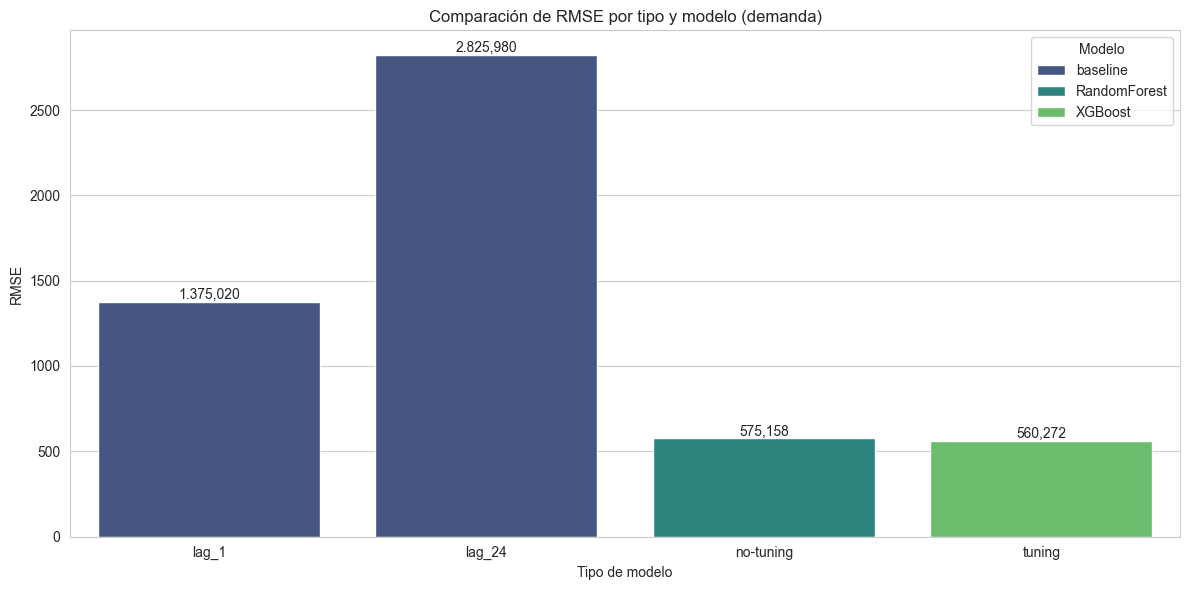

In [16]:
# Gráfico comparativo de resultados para la demanda
plt.figure(figsize=(12, 6))

sns.barplot(data=mejores_demanda, x="Tipo", y="RMSE", hue="Modelo", palette="viridis")

plt.title("Comparación de RMSE por tipo y modelo (demanda)")
plt.ylabel("RMSE")
plt.xlabel("Tipo de modelo")
for container in plt.gca().containers:
    plt.bar_label(container, labels=[f"{v:,.3f}".replace(",", "X").replace(".", ",").replace("X", ".") for v in container.datavalues], label_type='edge')
plt.xticks(rotation=0)
plt.legend(title="Modelo")
plt.tight_layout()
plt.show()

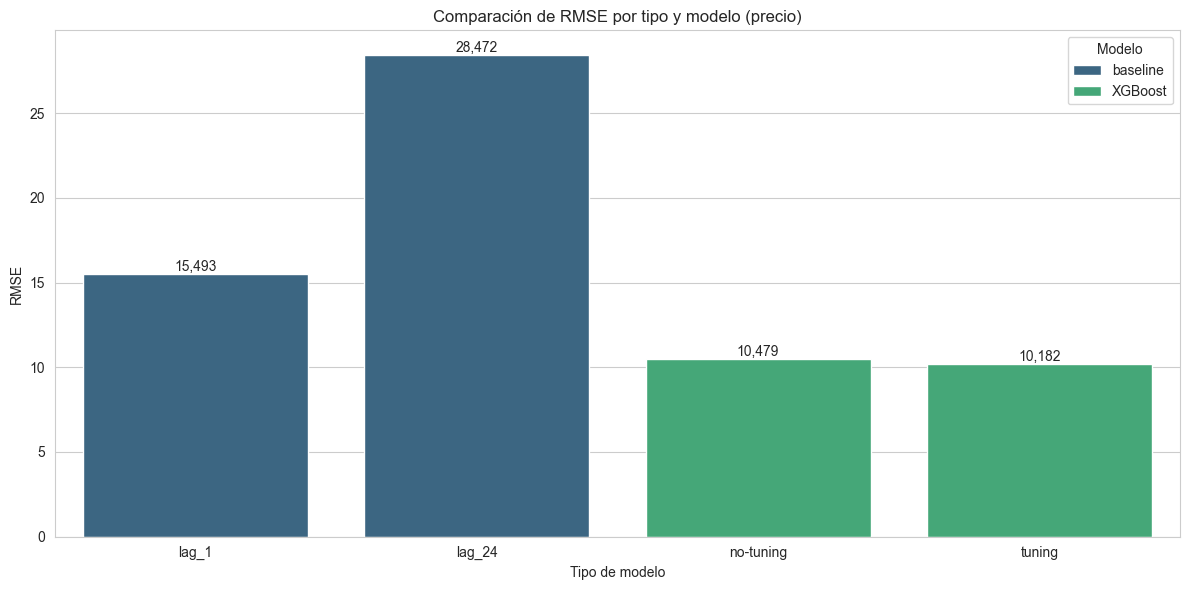

In [17]:
# Gráfico comparativo de resultados para el precio
plt.figure(figsize=(12, 6))

sns.barplot(data=mejores_precio, x="Tipo", y="RMSE", hue="Modelo", palette="viridis")

plt.title("Comparación de RMSE por tipo y modelo (precio)")
plt.ylabel("RMSE")
plt.xlabel("Tipo de modelo")
for container in plt.gca().containers:
    plt.bar_label(container, labels=[f"{v:,.3f}".replace(",", "X").replace(".", ",").replace("X", ".") for v in container.datavalues], label_type='edge')
plt.xticks(rotation=0)
plt.legend(title="Modelo")
plt.tight_layout()
plt.show()

# Predicción vs realidad

In [18]:
# Realizamos ahora la predicción con el mejor modelo y comparamos con la realidad
# Demanda
best_tuned_demanda.fit(x_train, y_train_demanda)
pred_demanda = best_tuned_demanda.predict(x_test)

# Precio
best_tuned_precio.fit(x_train, y_train_precio)
pred_precio = best_tuned_precio.predict(x_test)

# Porcentaje de error (suprimimos el warning para casos donde haya denominador igual a 0)
with np.errstate(divide='ignore', invalid='ignore'):
    demanda_pct_err = (pred_demanda - y_test_demanda.values) / y_test_demanda.values * 100
    demanda_pct_err[np.isinf(demanda_pct_err)] = np.nan
    precio_pct_err = (pred_precio - y_test_precio.values) / y_test_precio.values * 100
    precio_pct_err[np.isinf(precio_pct_err)] = np.nan

# Resultados finales
resultados_pred_vs_real = pd.DataFrame({
    "datetime"        : test["datetime"],
    "demanda_real"    : y_test_demanda.values,
    "demanda_pred"    : pred_demanda,
    "demanda_error"   : pred_demanda - y_test_demanda.values,
    "demanda_pct_err" : demanda_pct_err,
    "precio_real"     : y_test_precio.values,
    "precio_pred"     : pred_precio,
    "precio_error"    : pred_precio - y_test_precio.values,
    "precio_pct_err"  : precio_pct_err
})

display(resultados_pred_vs_real.head())

,datetime,demanda_real,demanda_pred,demanda_error,demanda_pct_err,precio_real,precio_pred,precio_error,precio_pct_err
52608,2025-01-01 00:00:00+01:00,23004.178,22826.566406,-177.611594,-0.772084,134.49,135.509827,1.019827,0.758292
52609,2025-01-01 01:00:00+01:00,22237.088,21762.335938,-474.752062,-2.134956,131.59,128.205231,-3.384769,-2.572209
52610,2025-01-01 02:00:00+01:00,21013.236,21368.929688,355.693687,1.692713,131.49,126.892754,-4.597246,-3.496271
52611,2025-01-01 03:00:00+01:00,19804.250,20536.160156,731.910156,3.695723,131.42,127.078339,-4.341661,-3.303653
52612,2025-01-01 04:00:00+01:00,19013.823,19459.771484,445.948484,2.345391,120.49,128.844376,8.354376,6.933667


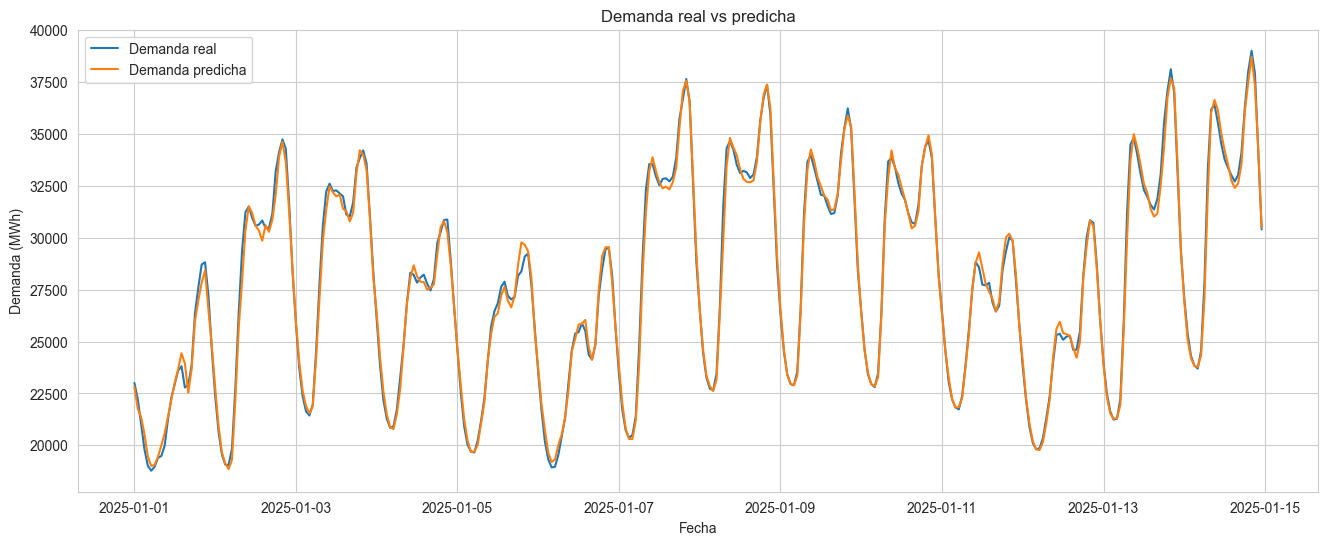

In [19]:
# Graficamos la demanda real vs la predicha
plot_data = resultados_pred_vs_real.iloc[:24*14] # Seleccionamos una ventana temporal de 2 semanas

plt.figure(figsize=(16,6))

plt.plot(plot_data["datetime"], plot_data["demanda_real"], label="Demanda real")
plt.plot(plot_data["datetime"], plot_data["demanda_pred"], label="Demanda predicha")

plt.title("Demanda real vs predicha")
plt.xlabel("Fecha")
plt.ylabel("Demanda (MWh)")

plt.legend()
plt.grid(True)
plt.show()

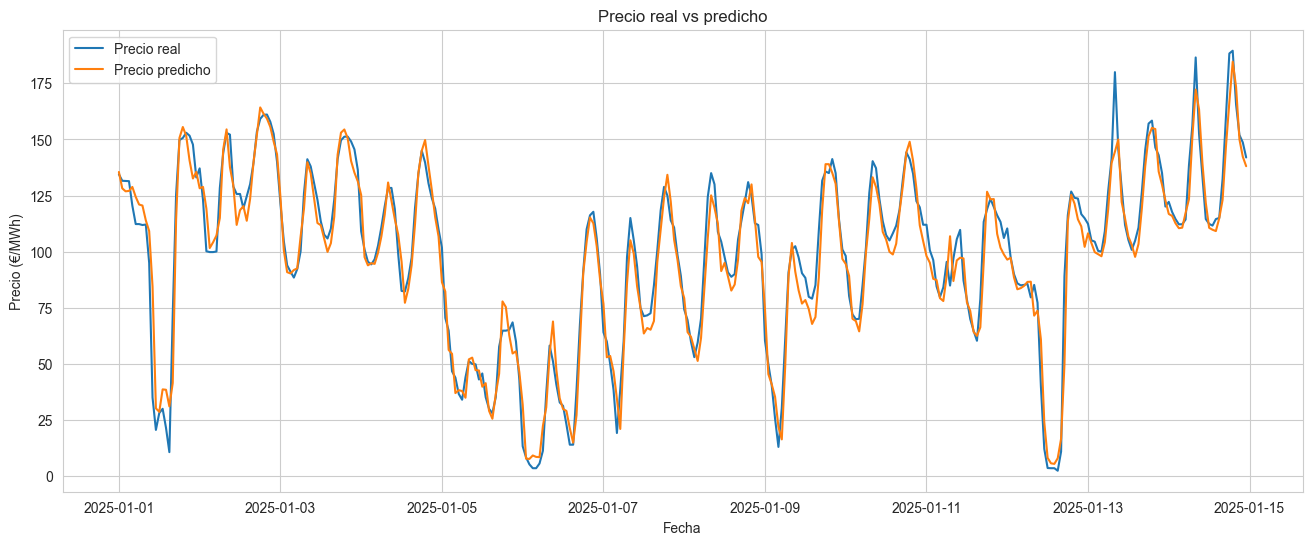

In [20]:
# Graficamos el precio real vs el predicho
plot_data = resultados_pred_vs_real.iloc[:24*14] # Seleccionamos una ventana temporal de 2 semanas

plt.figure(figsize=(16,6))

plt.plot(plot_data["datetime"], plot_data["precio_real"], label="Precio real")
plt.plot(plot_data["datetime"], plot_data["precio_pred"],label="Precio predicho")

plt.title("Precio real vs predicho")
plt.xlabel("Fecha")
plt.ylabel("Precio (€/MWh)")

plt.legend()
plt.grid(True)
plt.show()